In [11]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_excel(
    
    "/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/PROD_PUBINVESTMENT.xlsx", 
    sheet_name="Prod Pubinvestment"
)
df.head(10)

,STATE,YR,P_CAP,HWY,WATER,UTIL,PC,GSP,EMP,UNEMP
0,ALABAMA,1970,15032.67,7325.80,1655.68,6051.20,35793.80,28418,1010.5,4.7
1,ALABAMA,1971,15501.94,7525.94,1721.02,6254.98,37299.91,29375,1021.9,5.2
2,ALABAMA,1972,15972.41,7765.42,1764.75,6442.23,38670.30,31303,1072.3,4.7
3,ALABAMA,1973,16406.26,7907.66,1742.41,6756.19,40084.01,33430,1135.5,3.9
4,ALABAMA,1974,16762.67,8025.52,1734.85,7002.29,42057.31,33749,1169.8,5.5
5,ALABAMA,1975,17316.26,8158.23,1752.27,7405.76,43971.71,33604,1155.4,7.7
6,ALABAMA,1976,17732.86,8228.19,1799.74,7704.93,50221.57,35764,1207.0,6.8
7,ALABAMA,1977,18111.93,8365.67,1845.11,7901.15,51084.99,37463,1269.2,7.4
8,ALABAMA,1978,18479.74,8510.64,1960.51,8008.59,52604.05,39964,1336.5,6.3
9,ALABAMA,1979,18881.49,8640.61,2081.91,8158.97,54525.86,40979,1362.0,7.1


STATE = state name<br>
ST_ABB = state abbreviation<br>
YR = 1970,...,1986<br>
P_CAP = public capital<br>
HWY = highway capital<br>
WATER = water utility capital<br>
UTIL = utility capital<br>
PC = private capital<br>
GSP = gross state product<br>
EMP = employment<br>
UNEMP = unemployment rate<br>

In [13]:
df.tail(10)

,STATE,YR,P_CAP,HWY,WATER,UTIL,PC,GSP,EMP,UNEMP
806,WYOMING,1977,4037.03,2898.34,291.64,847.04,19977.67,9779,170.5,3.6
807,WYOMING,1978,4115.61,2920.85,294.73,900.04,20760.24,11038,187.4,3.3
808,WYOMING,1979,4268.71,2950.53,313.47,1004.71,21643.50,11988,200.7,2.8
809,WYOMING,1980,4399.69,2979.23,338.06,1082.40,22628.22,13027,210.2,4
810,WYOMING,1981,4572.67,3005.62,379.19,1187.86,26330.20,13717,223.5,4.1
811,WYOMING,1982,4731.98,3060.64,408.43,1262.90,27724.96,13056,217.7,5.8
812,WYOMING,1983,4950.82,3119.98,445.59,1385.25,28586.46,11922,202.5,8.4
813,WYOMING,1984,5184.73,3195.68,476.57,1512.48,28794.80,12073,204.3,6.3
814,WYOMING,1985,5448.38,3295.92,523.01,1629.45,29326.94,12022,206.9,7.1
815,WYOMING,1986,5700.41,3400.96,565.58,1733.88,27110.51,10870,196.3,9


In [14]:
model = smf.ols(
    formula="np.log(GSP) ~ np.log(P_CAP) + np.log(PC) + np.log(HWY) + np.log(WATER) + np.log(UTIL) + np.log(EMP)",
    data=df,
)
results = model.fit() 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(GSP)   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 1.971e+04
Date:                Sun, 01 Dec 2024   Prob (F-statistic):               0.00
Time:                        13:57:43   Log-Likelihood:                 862.28
No. Observations:                 816   AIC:                            -1711.
Df Residuals:                     809   BIC:                            -1678.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.2474      0.111     11.245

$$
lnGSP_{it} = \beta_1i +\beta_2 lnPCAP_{it} +\beta_3 lnHWY_{it} + \beta_4 lnWATER_{it} + \beta_5 lnUTIL_{it} + \beta_6 lnEMP_{it} + u_{it}
$$

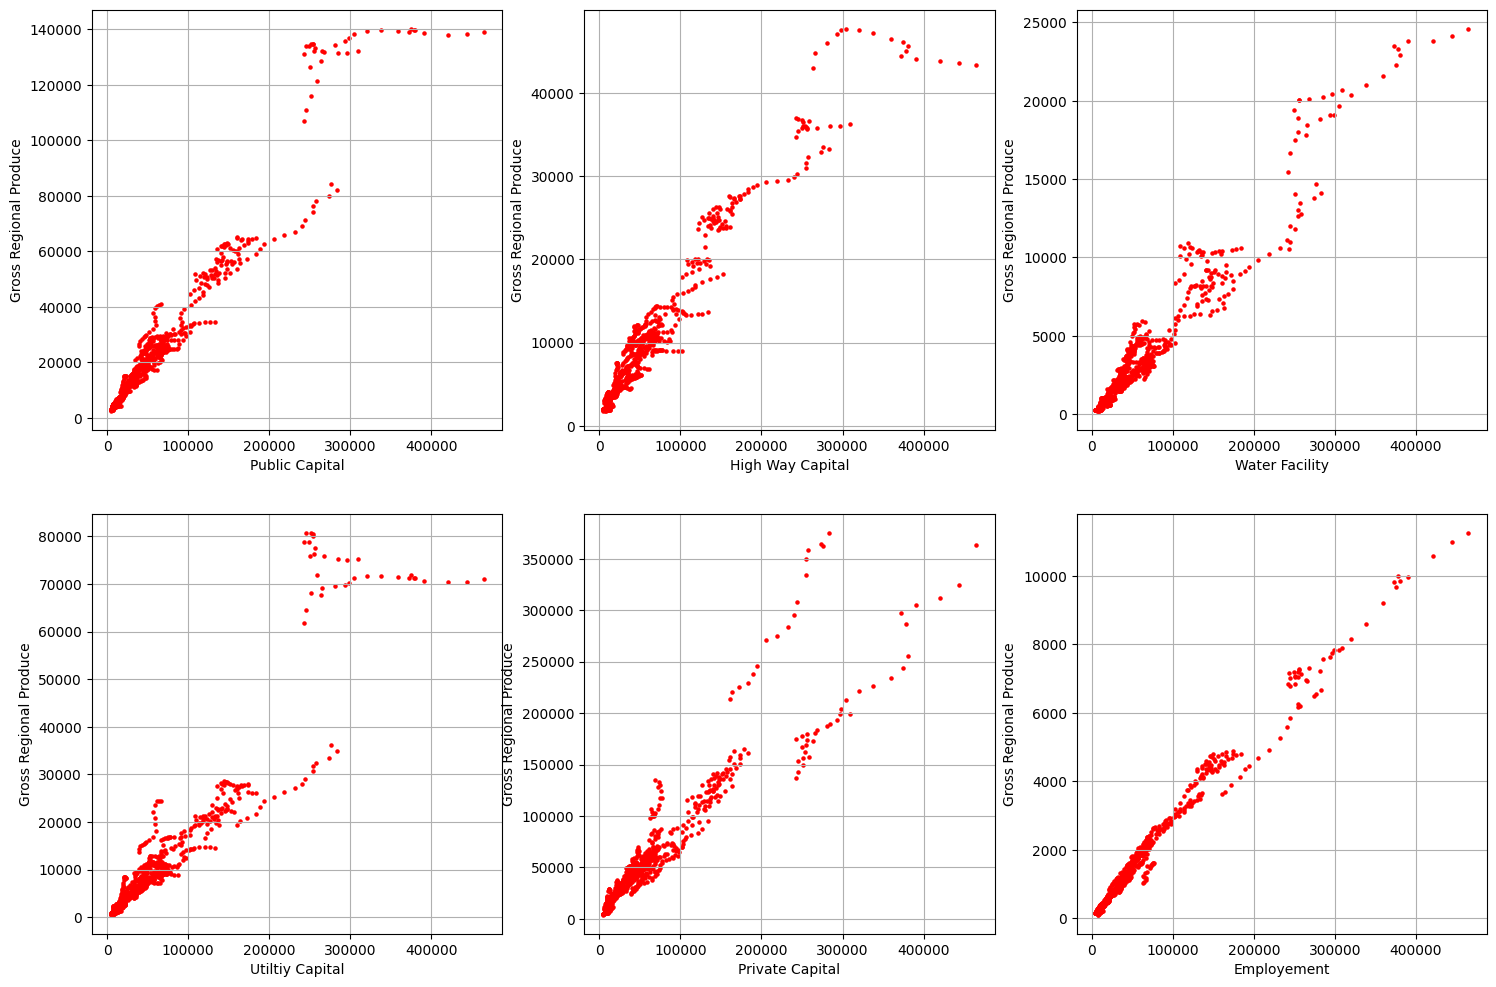

In [30]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
ax[0, 0].scatter(df["GSP"], df["P_CAP"], c="r", s=5)
ax[0, 0].grid()
ax[0, 0].set_xlabel("Public Capital")
ax[0, 0].set_ylabel("Gross Regional Produce")

ax[0, 1].scatter(df["GSP"], df["HWY"], c="r", s=5)
ax[0, 1].grid()
ax[0, 1].set_xlabel("High Way Capital")
ax[0, 1].set_ylabel("Gross Regional Produce")

ax[0, 2].scatter(df["GSP"], df["WATER"], c="r", s=5)
ax[0, 2].grid()
ax[0, 2].set_xlabel("Water Facility")
ax[0, 2].set_ylabel("Gross Regional Produce")

ax[1, 0].scatter(df["GSP"], df["UTIL"], c="r", s=5)
ax[1, 0].grid()
ax[1, 0].set_xlabel("Utiltiy Capital")
ax[1, 0].set_ylabel("Gross Regional Produce")

ax[1, 1].scatter(df["GSP"], df["PC"], c="r", s=5)
ax[1, 1].grid()
ax[1, 1].set_xlabel("Private Capital")
ax[1, 1].set_ylabel("Gross Regional Produce")

ax[1, 2].scatter(df["GSP"], df["EMP"], c="r", s=5)
ax[1, 2].grid()
ax[1, 2].set_xlabel("Employement")
ax[1, 2].set_ylabel("Gross Regional Produce")

plt.show()

In [19]:
print(df["STATE"].unique())
print(len(df["STATE"].unique()))

['ALABAMA' 'ARIZONA' 'ARKANSAS' 'CALIFORNIA' 'COLORADO' 'CONNECTICUT'
 'DELAWARE' 'FLORIDA' 'GEORGIA' 'IDAHO' 'ILLINOIS' 'INDIANA' 'IOWA'
 'KANSAS' 'KENTUCKY' 'LOUISIANA' 'MAINE' 'MARYLAND' 'MASSACHUSETTS'
 'MICHIGAN' 'MINNESOTA' 'MISSISSIPPI' 'MISSOURI' 'MONTANA' 'NEBRASKA'
 'NEVADA' 'NEW_HAMPSHIRE' 'NEW_JERSEY' 'NEW_MEXICO' 'NEW_YORK'
 'NORTH_CAROLINA' 'NORTH_DAKOTA' 'OHIO' 'OKLAHOMA' 'OREGON' 'PENNSYLVANIA'
 'RHODE_ISLAND' 'SOUTH_CAROLINA' 'SOUTH_DAKOTA' 'TENNESSE' 'TEXAS' 'UTAH'
 'VERMONT' 'VIRGINIA' 'WASHINGTON' 'WEST_VIRGINIA' 'WISCONSIN' 'WYOMING']
48


$$
lnGSP_{it} = \alpha_1 + \sum_{j=2}^{48} \alpha_j D_{ji} +\beta_2 lnPCAP_{it} + \beta_3 lnHWY_{it} + \beta_4 lnWATER_{it} + \beta_5 lnUTIL_{it} + \beta_6 lnEMP_{it} + u_{it}
$$

In [17]:
df_dum = pd.get_dummies(data=df, columns=["STATE"], drop_first=True)

In [18]:
df_dum

,YR,P_CAP,HWY,WATER,UTIL,PC,GSP,EMP,UNEMP,STATE_ARIZONA,...,STATE_SOUTH_DAKOTA,STATE_TENNESSE,STATE_TEXAS,STATE_UTAH,STATE_VERMONT,STATE_VIRGINIA,STATE_WASHINGTON,STATE_WEST_VIRGINIA,STATE_WISCONSIN,STATE_WYOMING
0,1970,15032.67,7325.80,1655.68,6051.20,35793.80,28418,1010.5,4.7,False,...,False,False,False,False,False,False,False,False,False,False
1,1971,15501.94,7525.94,1721.02,6254.98,37299.91,29375,1021.9,5.2,False,...,False,False,False,False,False,False,False,False,False,False
2,1972,15972.41,7765.42,1764.75,6442.23,38670.30,31303,1072.3,4.7,False,...,False,False,False,False,False,False,False,False,False,False
3,1973,16406.26,7907.66,1742.41,6756.19,40084.01,33430,1135.5,3.9,False,...,False,False,False,False,False,False,False,False,False,False
4,1974,16762.67,8025.52,1734.85,7002.29,42057.31,33749,1169.8,5.5,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,1982,4731.98,3060.64,408.43,1262.90,27724.96,13056,217.7,5.8,False,...,False,False,False,False,False,False,False,False,False,True
812,1983,4950.82,3119.98,445.59,1385.25,28586.46,11922,202.5,8.4,False,...,False,False,False,False,False,False,False,False,False,True
813,1984,5184.73,3195.68,476.57,1512.48,28794.80,12073,204.3,6.3,False,...,False,False,False,False,False,False,False,False,False,True
814,1985,5448.38,3295.92,523.01,1629.45,29326.94,12022,206.9,7.1,False,...,False,False,False,False,False,False,False,False,False,True


In [27]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.panel import compare

df = df.set_index(['STATE', 'YR'])

df = df.dropna()

X = df[['P_CAP', 'HWY', 'WATER', 'UTIL']]
y = df['EMP']

X = sm.add_constant(X)

pooled_ols = sm.OLS(y, X).fit()
print("Pooled OLS Results:")
print(pooled_ols.summary())

fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit()
print("\nFixed Effects Model Results:")
print(fe_results.summary)

re_model = RandomEffects(y, X)
re_results = re_model.fit()
print("\nRandom Effects Model Results:")
print(re_results.summary)

fe_betas = fe_results.params
re_betas = re_results.params

diff_betas = fe_betas - re_betas

fe_cov = fe_results.cov
re_cov = re_results.cov

inv_re_cov = np.linalg.inv(re_cov) 
hausman_stat = diff_betas.T @ inv_re_cov @ diff_betas

df = len(diff_betas) 
p_value = 1 - stats.chi2.cdf(hausman_stat, df)

print("\nHausman Test Results:")
print(f"Test statistic: {hausman_stat}")
print(f"P-value: {p_value}")

KeyError: "None of ['STATE', 'YR'] are in the columns"